This notebook is a pedagogical exploration of the hierarchy metrics from [Corominas-Murtra (2013) On the origins of hierarchy in complex networks](https://www.pnas.org/content/110/33/13316). The code for implementing these metrics was adapted from the [https://github.com/rkp8000/7UN3_1N_DR0P_0U7](https://github.com/rkp8000/7UN3_1N_DR0P_0U7) repo that accompanies Baker et al (2022).

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from scipy import stats

Note that the version of treeness implemented below does not go all the way to the version described in [Corominas-Murtra (2013)](https://www.pnas.org/content/110/33/13316). The "higher order" terms are missing. 

In [4]:
# hierarchy metrics
def get_gc(g):
    """Return graph condensation."""
    scc = list(nx.strongly_connected_components(g))
    gc = nx.algorithms.components.condensation(g, scc=scc)
    return gc, scc

def calc_treeness(gc):
    """Return treeness."""
    
    assert nx.is_directed_acyclic_graph(gc)
    
    k_ins = gc.in_degree()
    k_outs = gc.out_degree()
    
    max_nodes = np.array([v for v, k_in in k_ins if k_in == 0])
    min_nodes = np.array([v for v, k_out in k_outs if k_out == 0])
    
    if len(max_nodes) == len(min_nodes) == len(gc):
        return 0., 0., 0.
   
    h_fwds = []
    for v in max_nodes:
        # count all paths from v to each min_node
        paths = sum([list(nx.all_simple_paths(gc, v, u)) for u in min_nodes if (u != v and nx.has_path(gc, v, u))], [])
        
        if len(paths) == 0:
            h_fwds.append(0)  # only one path from v (to self), so 0 entropy
            continue
            
        p_paths = np.array([np.prod([1/k_outs[v_] for v_ in path[:-1]]) for path in paths])  # prob of path is product of all out_degrees along path
        
        np.testing.assert_almost_equal(np.sum(p_paths), 1)
        p_paths /= np.sum(p_paths)
        
        h_fwds.append(stats.entropy(p_paths, base=2))
        
    h_fwd = np.sum(h_fwds)/len(max_nodes)
    
    h_baks = []
    for u in min_nodes:
        # count all paths to u from each max_node
        paths = sum([list(nx.all_simple_paths(gc, v, u)) for v in max_nodes if (u != v and nx.has_path(gc, v, u))], [])
        
        if len(paths) == 0:
            h_fwds.append(0)  # only one path to u (from self), so 0 entropy
            continue
    
        p_paths = np.array([np.prod([1/k_ins[u_] for u_ in path[1:]]) for path in paths])  # prob of path is product of all in_degrees along path
        
        np.testing.assert_almost_equal(np.sum(p_paths), 1)
        p_paths /= np.sum(p_paths)
        
        h_baks.append(stats.entropy(p_paths, base=2))
        
    h_bak = np.sum(h_baks)/len(min_nodes)
    
    return (h_fwd - h_bak) / max(h_fwd, h_bak), h_fwd, h_bak


def calc_feedforwardness(gc):
    """Return feedforwardness"""
    k_ins = gc.in_degree()
    k_outs = gc.out_degree()
    
    max_nodes = np.array([v for v, k_in in k_ins if k_in == 0])
    min_nodes = np.array([v for v, k_out in k_outs if k_out == 0])
    
    if len(max_nodes) == len(min_nodes) == len(gc):
        return 0.
    
    alph = {i: len(gc.nodes[i]['members']) for i in gc.nodes()}
    
    paths_all = []
    p_paths_all = []

    for v in max_nodes:
#         paths = sum([list(nx.all_simple_paths(gc, v, u)) for u in min_nodes if nx.has_path(gc, v, u)], [])
        paths = sum([list(nx.all_simple_paths(gc, v, u)) for u in min_nodes if (u != v and nx.has_path(gc, v, u))], [])
        
        if len(paths) == 0:
            continue
            
        p_paths = [np.prod([1/k_outs[v_] for v_ in path[:-1]]) for path in paths]
        
        np.testing.assert_almost_equal(np.sum(p_paths), 1)
        p_paths /= np.sum(p_paths)
        
        paths_all.extend(paths)
        p_paths_all.extend(p_paths)
        
    p_paths_all = np.array(p_paths_all) / len(max_nodes)
    
    ffs = []
    
    for path in paths_all:
        
        ffs.append(len(path)/np.sum([alph[i] for i in path]))
    
    return np.mean(ffs)

def calc_orderability(gc):
    """Return orderability."""
    k_ins = gc.in_degree()
    k_outs = gc.out_degree()
    
    max_nodes = np.array([v for v, k_in in k_ins if k_in == 0])
    min_nodes = np.array([v for v, k_out in k_outs if k_out == 0])
       
    alph = np.array([len(gc.nodes[v]['members']) for v in gc.nodes() if (k_ins[v] or k_outs[v])])
    
    return np.sum(alph == 1)/alph.sum()

# Test graphs
We'll use dummy data to understand how to interpret Treeness, Feedforwardness, and Orderability. 

## Diverging feedforward graph
This is the example from Fig. 1A of [Corominas-Murtra (2013)](https://www.pnas.org/content/110/33/13316).

In [2]:
# adjacency matrix for a simple example graph
adj_a = np.array([
    [0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
])

In [3]:
# Create a directed graph from the adjacency matrix.
g_a = nx.from_numpy_array(adj_a, create_using=nx.DiGraph)

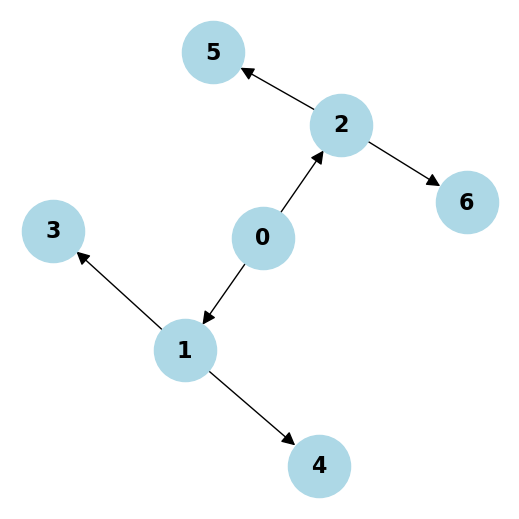

In [ ]:
# Display the graph as a tree
plt.figure(figsize=(3, 3))
pos = nx.spring_layout(g_a)
nx.draw(g_a, pos, with_labels=True, node_color='lightblue', node_size=1000, font_size=16, font_weight='bold', arrowsize=20)
plt.axis('off')
plt.show()

We'll get the Strongly Connected Components (SCC) from the graph and a condensed graph where the SCCs are the nodes. This new graph will be a Directed Acyclic Graph (DAG) meaning it has no cycles.

In [31]:
gc_a, scc_a = get_gc(g_a)

In [37]:
scc_a

[{3}, {4}, {1}, {5}, {6}, {2}, {0}]

In [35]:
# The condensed graph should be acyclic, which is required for the hierarchy layout.
nx.is_directed_acyclic_graph(gc_a)

True

I tried just doing something simple and plotting the condensed graph as-is. I'm wondering why the nodes are labeled differently. They don't seem to inherit the node labels from the original graph even though each node in that graph is apparently its own SCC. In fact, the order of node labeling appears to get reversed in the condensed graph. I will need to confirm that this doesn't cause any issues with the hierarchy computations. 

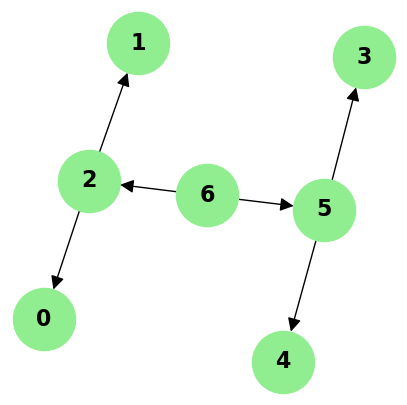

In [38]:
# plot the condensed graph
fig, ax = plt.subplots(figsize=(5, 5))
pos = nx.spring_layout(gc_a)
nx.draw(gc_a, pos, with_labels=True, node_color='lightgreen', node_size=2000, font_size=16, font_weight='bold', arrowsize=20)
plt.axis('off')
plt.show()

In [45]:
def draw_condensed_graph(gc):
    """Draw a condensed graph with node sizes scaled by component size."""
    node_list = np.array(list(gc.nodes()))
    k_ins = dict(gc.in_degree())
    k_outs = dict(gc.out_degree())

    max_nodes = np.array([v for v in node_list if k_ins[v] == 0])
    xs = {v: 0 for v in max_nodes}
    member_dict = {v: gc.nodes[v]['members'] for v in node_list}

    prev_nodes = max_nodes.copy()
    for i in range(100):
        child_list = sum([list(gc.successors(v)) for v in prev_nodes], [])

        if not child_list:
            break

        next_nodes = np.array(list(set(child_list)))
        for v in next_nodes:
            xs[v] = i + 1

        prev_nodes = next_nodes
    else:
        raise Exception('for loop reached 100 iters')

    for v in node_list:
        if k_ins[v] == k_outs[v] == 0:
            xs[v] = np.nan

    connected_xs = [x for x in xs.values() if not np.isnan(x)]
    x_max = max(connected_xs, default=0)
    for v in node_list:
        if k_outs[v] == 0 and k_ins[v] > 0:
            xs[v] = x_max

    ys = {v: np.nan for v in node_list}
    for x_ in set(xs.values()):
        nodes_this_x = [v for v in node_list if xs[v] == x_]
        ys_ = np.random.permutation(len(nodes_this_x))
        for y_, v_ in zip(ys_, nodes_this_x):
            ys[v_] = y_ - len(nodes_this_x) / 2

    pos = {v: (xs[v], ys[v]) for v in node_list}
    alphs = np.array([len(member_dict[v]) for v in node_list])

    unconnected = [v for v in node_list if np.isnan(pos[v][0])]
    n_unconnected = len(unconnected)
    connected_xs = [x for x in xs.values() if not np.isnan(x)]
    connected_ys = [y for y in ys.values() if not np.isnan(y)]
    xr = max(connected_xs) - min(connected_xs) if connected_xs else 1
    y_max = max(connected_ys, default=0)
    x_unc = min(connected_xs, default=0) + xr / 50 * (np.arange(n_unconnected) % 50)
    y_unc = y_max * (1.25 + .05 * (np.arange(n_unconnected) // 50))

    for cv, v in enumerate(unconnected):
        pos[v] = (x_unc[cv], y_unc[cv])

    fig, ax = plt.subplots(1, 1, figsize=(5, 5), tight_layout=True)
    nx.draw_networkx(gc, pos=pos, node_size=10, ax=ax, with_labels=False, arrows=False, arrowsize=10)
    ax.scatter(*zip(*[pos[v] for v in node_list]), s=25 * alphs, zorder=1000, c='limegreen')
    ax.set_title(f'Condensed graph ({n_unconnected} unconnected nodes)')

    return fig, ax

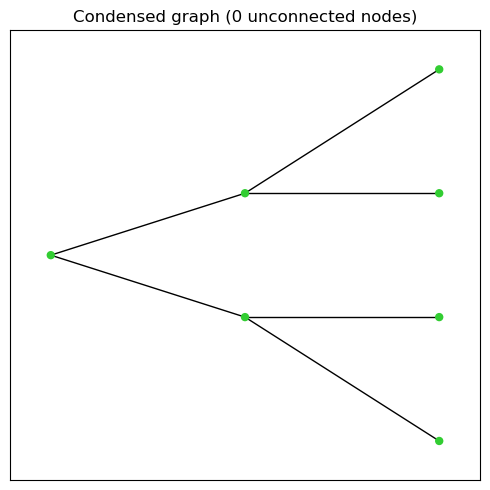

In [46]:
draw_condensed_graph(gc_a)
plt.show()

We compute the hierarchy metrics for this simple example below. 

**Treeness** (−1 ≤ T ≤ 1) tells us "how pyramidal is the structure and how unambiguous is its chain of command". This example graph is perfectly tree-like and should give T=1.

**Feedforwardness** (F, being 0 ≤ F ≤ 1) is "a measure that weights the impact of cyclic modules on the feedforward structure, where cyclic modules closer to the top of G introduce a larger penalty on hierarchical order than those placed at the bottom". This example graph should give F=1.

**Orderability** "lies in the range 0 ≤ O ≤ 1 and it is defined as the fraction of the nodes of the graph G that does not belong to any cycle". None of the nodes belongs to a cycle, so O=1 in this exmaple.

In [48]:
# treeness
t_a = calc_treeness(gc_a)[0]

# feedforwardness
f_a = calc_feedforwardness(gc_a)

# orderability
o_a = calc_orderability(gc_a)

print(f'T(A) = {t_a}, F(A) = {f_a}, O(A) = {o_a}')

T(A) = 1.0, F(A) = 1.0, O(A) = 1.0


## Converging feedforward graph
This is the example from Fig. 1B of [Corominas-Murtra (2013)](https://www.pnas.org/content/110/33/13316). The metrics should be T=-1, F=1, O=1. 

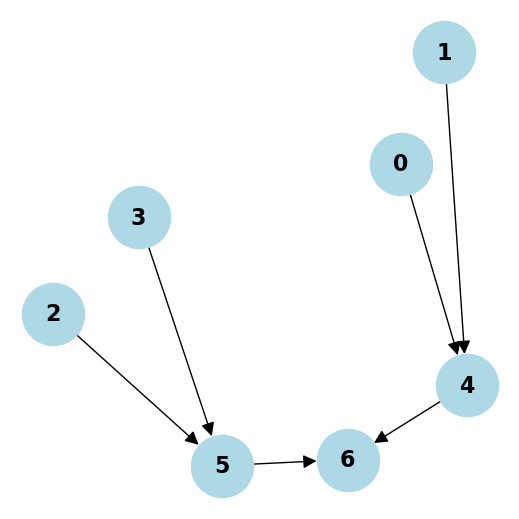

In [ ]:
# adjacency matrix for a simple example graph
adj_b = np.array([
    [0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 0],
])

# Create a directed graph from the adjacency matrix.
g_b = nx.from_numpy_array(adj_b, create_using=nx.DiGraph)

# Display the graph as a tree
plt.figure(figsize=(3, 3))
pos = nx.spring_layout(g_b)
nx.draw(g_b, pos, with_labels=True, node_color='lightblue', node_size=1000, font_size=16, font_weight='bold', arrowsize=20)
plt.axis('off')
plt.show()

In [50]:
# Compute the graph condensation.
gc_b, scc_b = get_gc(g_b)

Is there any reason to allow connections to cross? Seems messy. Try fixing this in the draw_condensed_graph function.

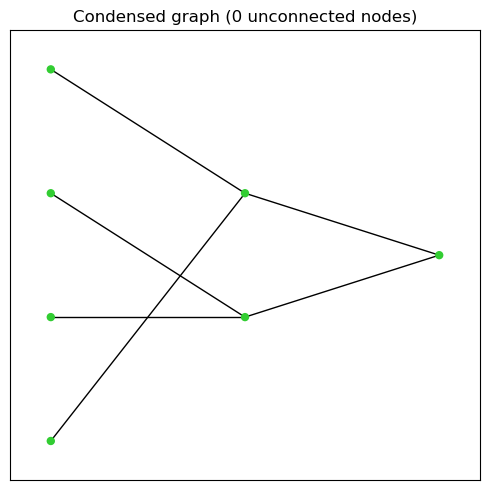

In [51]:
# draw the condensed graph
draw_condensed_graph(gc_b)
plt.show()

In [52]:
# treeness
t_b = calc_treeness(gc_b)[0]
# feedforwardness
f_b = calc_feedforwardness(gc_b)
# orderability
o_b = calc_orderability(gc_b)

print(f'T(B) = {t_b}, F(A) = {f_b}, O(B) = {o_b}')

T(B) = -1.0, F(A) = 1.0, O(B) = 1.0


## Converging and diverging graph
This one has no treeness even though it is perfectly feedforward and perfectly orderable. Example from Fig. 1C of [Corominas-Murtra (2013)](https://www.pnas.org/content/110/33/13316). T=0, F=1, O=1.

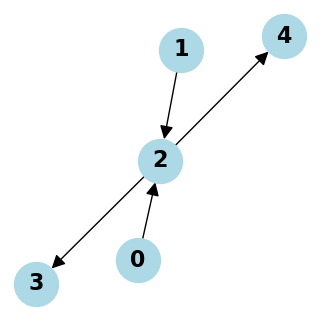

In [54]:
# adjacency matrix for a simple example graph
adj_c = np.array([
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 1, 1],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
])

# Create a directed graph from the adjacency matrix.
g_c = nx.from_numpy_array(adj_c, create_using=nx.DiGraph)

# Display the graph as a tree
plt.figure(figsize=(3, 3))
pos = nx.spring_layout(g_c)
nx.draw(g_c, pos, with_labels=True, node_color='lightblue', node_size=1000, font_size=16, font_weight='bold', arrowsize=20)
plt.axis('off')
plt.show()

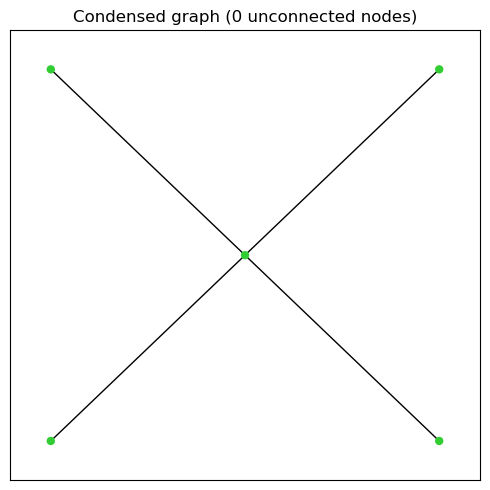

In [55]:
# Compute the graph condensation.
gc_c, scc_c = get_gc(g_c)

# draw the condensed graph
draw_condensed_graph(gc_c)
plt.show()

In [ ]:
# treeness
t_c = calc_treeness(gc_c)[0]
# feedforwardness
f_c = calc_feedforwardness(gc_c)
# orderability
o_c = calc_orderability(gc_c)

print(f'T(C) = {t_c}, F(A) = {f_c}, O(C) = {o_c}')

T(C) = 0.0, F(A) = 1.0, O(C) = 1.0


## Graph with cycles
Now we're cooking. This graph has maximal treeness. The order of command is clear. But the SCCs are like departments. Sometimes business sticks around within a department, and it makes it harder to order the nodes.
Example from Fig. 1D of [Corominas-Murtra (2013)](https://www.pnas.org/content/110/33/13316). T=1, F=0.6, O=0.5.

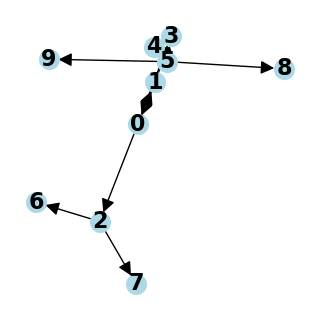

In [60]:
# adjacency matrix for a simple example graph
adj_d = np.array([
    [0, 1, 1, 1, 0, 0, 0, 0, 0, 0],
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
])

# Create a directed graph from the adjacency matrix.
g_d = nx.from_numpy_array(adj_d, create_using=nx.DiGraph)

# draw the directed graph
plt.figure(figsize=(3, 3))
pos = nx.spring_layout(g_d)
nx.draw(g_d, pos, with_labels=True, node_color='lightblue', node_size=200, font_size=16, font_weight='bold', arrowsize=20)
plt.axis('off')
plt.show()

Notice how the condensed graph resembles the directed graph from example A.

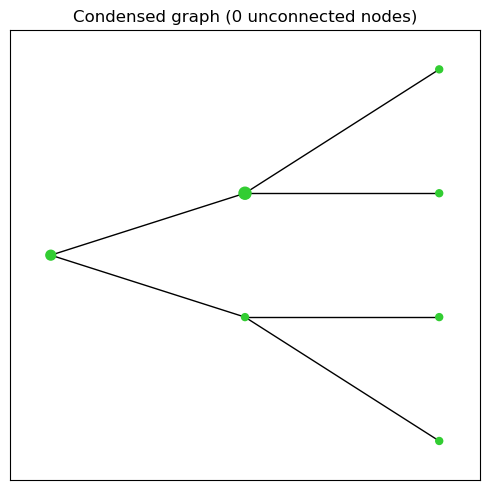

In [61]:
# compute the graph condensation.
gc_d, scc_d = get_gc(g_d)

# draw the condensed graph
draw_condensed_graph(gc_d)
plt.show()

In [62]:
# treeness
t_d = calc_treeness(gc_d)[0]
# feedforwardness
f_d = calc_feedforwardness(gc_d)
# orderability
o_d = calc_orderability(gc_d)

print(f'T(D) = {t_d}, F(A) = {f_d}, O(D) = {o_d}')

T(D) = 1.0, F(A) = 0.625, O(D) = 0.5


Should be:

`T(A) = 1.0, F(A) = 1.0, O(A) = 1.0`

`T(B) = -1.0, F(A) = 1.0, O(B) = 1.0`

`T(C) = 0.0, F(A) = 1.0, O(C) = 1.0`

`T(D) = 1.0, F(A) = 0.625, O(D) = 0.5`

## Another example
Using the example from Fig. 14 of the supplementary material of [Corominas-Murtra (2013)](https://www.pnas.org/content/110/33/13316), I confirmed that the Treeness and Feedforwardness calculations implemented in Baker et al (2022) are missing the higher order components of the algorithms. In that example, we should get T=-0.55, F=0.56, O=0.43. Orderability is correct because it doesn't have additional components and it is simply computed on the whole graph. However, we obtained values for T and F that are only for the first term of each calculation. 

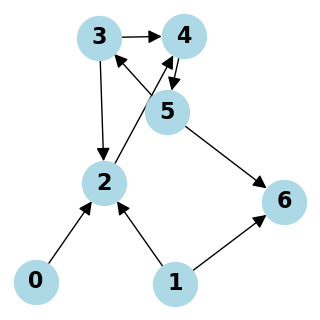

In [70]:
# adjacency matrix for a simple example graph
adj_e = np.array([
    [0, 0, 1, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 1],
    [0, 0, 0, 0, 1, 0, 0],
    [0, 0, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 0],
])

# Create a directed graph from the adjacency matrix.
g_e = nx.from_numpy_array(adj_e, create_using=nx.DiGraph)

# Display the graph as a tree
plt.figure(figsize=(3, 3))
pos = nx.spring_layout(g_e)
nx.draw(g_e, pos, with_labels=True, node_color='lightblue', node_size=1000, font_size=16, font_weight='bold', arrowsize=20)
plt.axis('off')
plt.show()

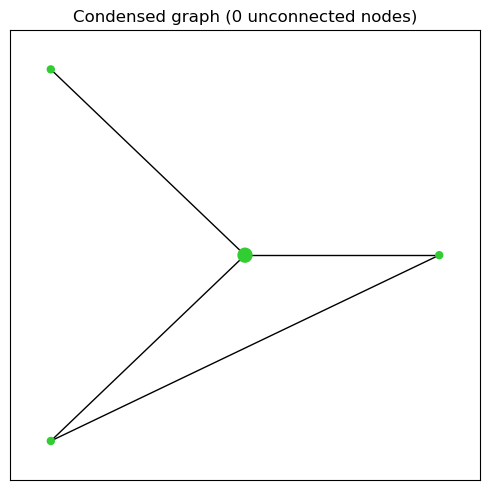

In [71]:
# compute the graph condensation.
gc_e, scc_e = get_gc(g_e)

# draw the condensed graph
draw_condensed_graph(gc_e)
plt.show()

In [72]:
# treeness
t_e = calc_treeness(gc_e)[0]
# feedforwardness
f_e = calc_feedforwardness(gc_e)
# orderability
o_e = calc_orderability(gc_e)

print(f'T(D) = {t_e}, F(A) = {f_e}, O(D) = {o_e}')

T(D) = -0.6666666666666666, F(A) = 0.6666666666666666, O(D) = 0.42857142857142855


# The corrected hierarchy functions